# CVAE- Ayelo2026

# Etapa 3

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DB_PATH = "../db/tfm_vocs.db"
PARQUET_PATH = "../db/data/processed/abundancias_ayelo2026.csv"
DATASET_ORIGIN = "Ayelo2026"

In [2]:
import pickle
import numpy as np
from pathlib import Path

MODELS_DIR = Path("../models")

def export_cvae(dataset_slug, encoder, decoder, iso_forest, autoencoder,
                 scores_loo, errores_loo_ae, scaler, compound_ids, meta=None):
    out = MODELS_DIR / dataset_slug
    out.mkdir(parents=True, exist_ok=True)
    encoder.save(out / "cvae_encoder.keras")
    decoder.save(out / "cvae_decoder.keras")
    autoencoder.save(out / "autoencoder.keras")

    with open(out / "isolation_forest.pkl", "wb") as f:
        pickle.dump(iso_forest, f)
    with open(out / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    with open(out / "compound_ids.pkl", "wb") as f:
        pickle.dump(list(compound_ids), f)

    np.save(out / "scores_loo.npy", scores_loo)
    np.save(out / "errores_loo_ae.npy", errores_loo_ae)

    if meta:
        with open(out / "cvae_meta.pkl", "wb") as f:
            pickle.dump(meta, f)

    print(f"Exportado CVAE+detectores: {dataset_slug} -> {out}")

In [3]:
SEED = 42
tf.keras.utils.set_random_seed(SEED)

### Carga de datos

In [4]:
con = sqlite3.connect(DB_PATH)

muestras = pd.read_sql(
    f"SELECT * FROM muestras WHERE dataset_origin = '{DATASET_ORIGIN}'", con
)
compuestos = pd.read_sql(
    f"SELECT * FROM compuestos WHERE dataset_origin = '{DATASET_ORIGIN}'", con
)
abundancias = pd.read_csv(PARQUET_PATH)

con.close()

print("Muestras:", muestras.shape)
print("Compuestos:", compuestos.shape)
print("Abundancias:", abundancias.shape)
print("\nphysiological_state:")
print(muestras["physiological_state"].value_counts())
print("\nspecies:")
print(muestras["species"].value_counts())
print("\nNulos en abundancia:", abundancias["abundancia"].isna().sum())

muestras.head()

Muestras: (60, 19)
Compuestos: (13, 15)
Abundancias: (780, 4)

physiological_state:
physiological_state
herbivory_exposed    50
control              10
Name: count, dtype: int64

species:
species
Gossypium hirsutum    60
Name: count, dtype: int64

Nulos en abundancia: 0


,sample_id,species,genotype,genotype_notes,microorganism,strain,physiological_state,dataset_origin,doi,analytical_technique,timepoint,tissue,experiment_replicate,biological_replicate,load_date,validation_status,intended_use,eje_biologico,metadata_extra
0,ayelo2026_rc_ctrl_r01,Gossypium hirsutum,None,None,None,None,control,Ayelo2026,10.1002/ps.70789,GC-MS (foliar headspace),None,leaves,None,1,2026-07-07,pendiente_validacion,classifier,resistencia_cultivar_herbivoria,"{""cultivar_code"": ""RC"", ""cultivar_resistance"":..."
1,ayelo2026_rc_ctrl_r02,Gossypium hirsutum,None,None,None,None,control,Ayelo2026,10.1002/ps.70789,GC-MS (foliar headspace),None,leaves,None,2,2026-07-07,pendiente_validacion,classifier,resistencia_cultivar_herbivoria,"{""cultivar_code"": ""RC"", ""cultivar_resistance"":..."
2,ayelo2026_rc_ctrl_r03,Gossypium hirsutum,None,None,None,None,control,Ayelo2026,10.1002/ps.70789,GC-MS (foliar headspace),None,leaves,None,3,2026-07-07,pendiente_validacion,classifier,resistencia_cultivar_herbivoria,"{""cultivar_code"": ""RC"", ""cultivar_resistance"":..."
3,ayelo2026_rc_ctrl_r04,Gossypium hirsutum,None,None,None,None,control,Ayelo2026,10.1002/ps.70789,GC-MS (foliar headspace),None,leaves,None,4,2026-07-07,pendiente_validacion,classifier,resistencia_cultivar_herbivoria,"{""cultivar_code"": ""RC"", ""cultivar_resistance"":..."
4,ayelo2026_rc_ctrl_r05,Gossypium hirsutum,None,None,None,None,control,Ayelo2026,10.1002/ps.70789,GC-MS (foliar headspace),None,leaves,None,5,2026-07-07,pendiente_validacion,classifier,resistencia_cultivar_herbivoria,"{""cultivar_code"": ""RC"", ""cultivar_resistance"":..."


In [5]:
#Chequeo de contaminantes
pd.set_option("display.max_rows", None)
compuestos[["compuesto_id", "name_original", "cas", "pubchem_cid"]]

,compuesto_id,name_original,cas,pubchem_cid
0,ayelo2026_cmp001,alpha-Pinene,None,6654.0
1,ayelo2026_cmp002,Benzaldehyde,None,240.0
2,ayelo2026_cmp003,beta-Pinene,None,14896.0
3,ayelo2026_cmp004,beta-Myrcene,None,31253.0
4,ayelo2026_cmp005,(Z)-3-Hexenyl acetate,None,5363388.0
5,ayelo2026_cmp006,D-Limonene,None,440917.0
6,ayelo2026_cmp007,beta-Ocimene,None,18756.0
7,ayelo2026_cmp008,Nonanal,None,31289.0
8,ayelo2026_cmp009,"DMNT (4,8-dimethylnona-1,3,7-triene)",None,6427110.0
9,ayelo2026_cmp010,Decanal,None,8175.0


In [6]:
print(muestras["genotype"].value_counts(dropna=False))

import json
cultivares = muestras["metadata_extra"].apply(lambda x: json.loads(x).get("cultivar_code") if x else None)
print(cultivares.value_counts(dropna=False))

resistencia = muestras["metadata_extra"].apply(lambda x: json.loads(x).get("cultivar_resistance") if x else None)
print(resistencia.value_counts(dropna=False))

pd.crosstab(cultivares, muestras["physiological_state"])

genotype
None    60
Name: count, dtype: int64
metadata_extra
RC    30
SC    30
Name: count, dtype: int64
metadata_extra
resistant      30
susceptible    30
Name: count, dtype: int64


physiological_state,control,herbivory_exposed
metadata_extra,,
RC,5,25
SC,5,25


### Preprocesamiento

In [7]:
#Pivot
wide = abundancias.pivot(index="sample_id", columns="compuesto_id", values="abundancia")
print("Nulos en wide:", wide.isna().sum().sum())
print("Shape wide:", wide.shape)
wide.head()

Nulos en wide: 0
Shape wide: (60, 13)


compuesto_id,ayelo2026_cmp001,ayelo2026_cmp002,ayelo2026_cmp003,ayelo2026_cmp004,ayelo2026_cmp005,ayelo2026_cmp006,ayelo2026_cmp007,ayelo2026_cmp008,ayelo2026_cmp009,ayelo2026_cmp010,ayelo2026_cmp011,ayelo2026_cmp012,ayelo2026_cmp013
sample_id,,,,,,,,,,,,,
ayelo2026_rc_au8_r01,384.72,24.91,48.29,34.65,21.22,16.93,4.72,3.68,41.30,0.00,30.82,7.02,8.31
ayelo2026_rc_au8_r02,245.79,11.62,36.15,38.28,50.43,13.58,10.35,6.85,189.93,0.00,38.18,8.95,10.64
ayelo2026_rc_au8_r03,181.94,20.06,72.22,94.06,71.38,30.03,8.24,3.05,65.50,0.00,59.92,14.53,14.34
ayelo2026_rc_au8_r04,134.29,29.70,19.71,23.14,6.33,8.40,2.70,4.23,5.23,0.00,12.62,3.49,3.98
ayelo2026_rc_au8_r05,164.63,274.92,265.72,438.16,279.86,129.87,139.39,21.13,398.49,41.14,330.57,71.83,40.70


In [8]:
#Log1p
X_log = np.log1p(wide.values)
print("X_log shape:", X_log.shape)

X_log shape: (60, 13)


In [9]:
#Composición + split
estado = muestras.set_index("sample_id").loc[wide.index, "physiological_state"]

cond_dummies = pd.get_dummies(estado, drop_first=True).astype(float)
print("Columnas de condición:", cond_dummies.columns.tolist())
cond_dummies.head()

Columnas de condición: ['herbivory_exposed']


,herbivory_exposed
sample_id,
ayelo2026_rc_au8_r01,1.0
ayelo2026_rc_au8_r02,1.0
ayelo2026_rc_au8_r03,1.0
ayelo2026_rc_au8_r04,1.0
ayelo2026_rc_au8_r05,1.0


In [10]:
# División tr/ts
X_train, X_val, y_train, y_val = train_test_split(
    X_log, cond_dummies.values,
    test_size=0.2, stratify=estado, random_state=42
)

print("X_train:", X_train.shape, " X_val:", X_val.shape)
print("y_train:", y_train.shape, " y_val:", y_val.shape)
print("\nDistribución train:", pd.Series(y_train.flatten()).value_counts().to_dict())
print("Distribución val:", pd.Series(y_val.flatten()).value_counts().to_dict())

X_train: (48, 13)  X_val: (12, 13)
y_train: (48, 1)  y_val: (12, 1)

Distribución train: {1.0: 40, 0.0: 8}
Distribución val: {1.0: 10, 0.0: 2}


In [11]:
# Estandarización
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

print(X_train_s.shape, X_val_s.shape)

(48, 13) (12, 13)


## Encoder

In [12]:
input_dim = X_train_s.shape[1]
cond_dim = y_train.shape[1]
latent_dim = 2

encoder_inputs = keras.Input(shape=(input_dim,), name="x_input")
encoder_cond = keras.Input(shape=(cond_dim,), name="cond_input")
x = layers.concatenate([encoder_inputs, encoder_cond])
x = layers.Dense(16, activation="relu")(x)
x = layers.Dense(8, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

encoder = keras.Model([encoder_inputs, encoder_cond], [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ x_input (InputLayer)          │ (None, 13)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cond_input (InputLayer)       │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 14)                │               0 │ x_input[0][0],             │
│                               │                           │                 │ cond_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 16)                │             240 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 8)                 │             136 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 2)                 │              18 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 2)                 │              18 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z (Lambda)                    │ (None, 2)                 │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 412 (1.61 KB)

 Trainable params: 412 (1.61 KB)

 Non-trainable params: 0 (0.00 B)

## Decoder

In [13]:
latent_inputs = keras.Input(shape=(latent_dim,), name="z_input")
decoder_cond = keras.Input(shape=(cond_dim,), name="cond_input_dec")
x = layers.concatenate([latent_inputs, decoder_cond])
x = layers.Dense(8, activation="relu")(x)
x = layers.Dense(16, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="linear")(x)

decoder = keras.Model([latent_inputs, decoder_cond], decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ z_input (InputLayer)          │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cond_input_dec (InputLayer)   │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 3)                 │               0 │ z_input[0][0],             │
│                               │                           │                 │ cond_input_dec[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 8)                 │              32 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 16)                │             144 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 13)                │             221 │ dense_3[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 397 (1.55 KB)

 Trainable params: 397 (1.55 KB)

 Non-trainable params: 0 (0.00 B)

## CVAE

In [14]:
class CVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
        self.beta = tf.Variable(1.0, trainable=False, dtype=tf.float32)

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _compute_losses(self, x, cond):
        z_mean, z_log_var, z = self.encoder([x, cond])
        reconstruction = self.decoder([z, cond])
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - reconstruction), axis=1))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x, cond = data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(x, cond)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, cond = data
        total_loss, recon_loss, kl_loss = self._compute_losses(x, cond)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

## Entrenamiento

In [15]:
class KLWarmup(keras.callbacks.Callback):
    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        new_beta = min(1.0, epoch / (self.total_epochs * 0.5))
        self.model.beta.assign(new_beta)

cvae = CVAE(encoder, decoder)
cvae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

EPOCHS = 300
BATCH_SIZE = 16

history = cvae.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[KLWarmup(EPOCHS)],
    verbose=0,
)

n_ultimas = 30
print("Promedio últimas", n_ultimas, "épocas:")
print("recon_loss (train):", np.mean(history.history["recon_loss"][-n_ultimas:]))
print("recon_loss (val):", np.mean(history.history["val_recon_loss"][-n_ultimas:]))
print("kl_loss (train):", np.mean(history.history["kl_loss"][-n_ultimas:]))
print("kl_loss (val):", np.mean(history.history["val_kl_loss"][-n_ultimas:]))

Entrenamiento terminado.
Promedio últimas 30 épocas:
recon_loss (train): 3.660621698697408
recon_loss (val): 3.7531706571578978
kl_loss (train): 2.114481631914775
kl_loss (val): 2.291617767016093


## Curva de pérdida

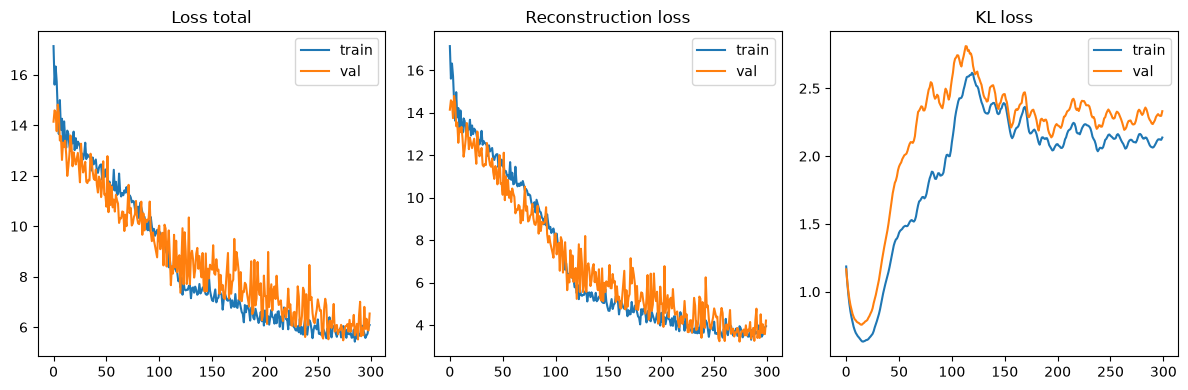

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss total")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history["recon_loss"], label="train")
plt.plot(history.history["val_recon_loss"], label="val")
plt.title("Reconstruction loss")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history["kl_loss"], label="train")
plt.plot(history.history["val_kl_loss"], label="val")
plt.title("KL loss")
plt.legend()

plt.tight_layout()
plt.show()

## Chequeo de reocnstrucción

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


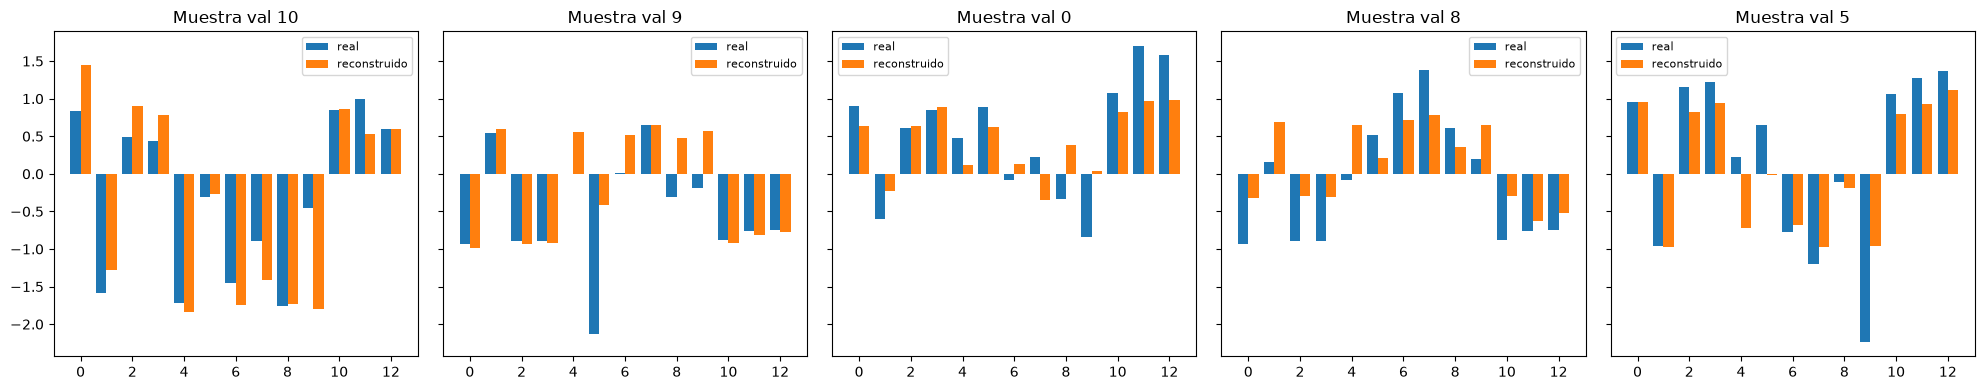

In [17]:
n_muestras = 5
idx_muestra = np.random.choice(len(X_val_s), n_muestras, replace=False)

z_mean_val, z_log_var_val, z_val = encoder.predict([X_val_s, y_val])
reconstruccion_val = decoder.predict([z_val, y_val])

fig, axes = plt.subplots(1, n_muestras, figsize=(4 * n_muestras, 4), sharey=True)
for ax, i in zip(axes, idx_muestra):
    ax.bar(np.arange(input_dim) - 0.2, X_val_s[i], width=0.4, label="real")
    ax.bar(np.arange(input_dim) + 0.2, reconstruccion_val[i], width=0.4, label="reconstruido")
    ax.set_title(f"Muestra val {i}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Espacio Latente

Labels de validación: ['herbivory_exposed' 'herbivory_exposed' 'herbivory_exposed'
 'herbivory_exposed' 'herbivory_exposed' 'herbivory_exposed'
 'herbivory_exposed' 'control' 'herbivory_exposed' 'herbivory_exposed'
 'herbivory_exposed' 'control']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


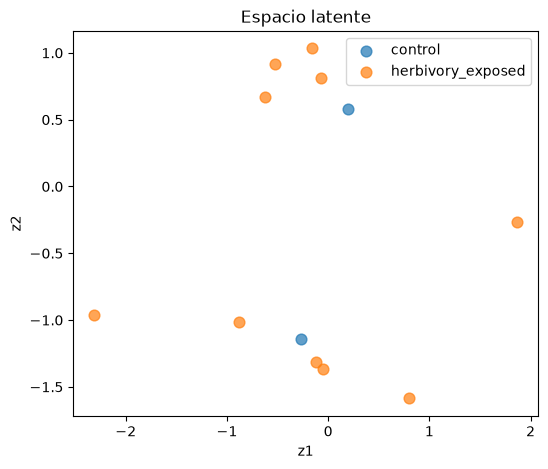

Silhouette score (validación): -0.22218047082424164


In [18]:
from sklearn.metrics import silhouette_score

labels_val = np.where(y_val.flatten() == 1, "herbivory_exposed", "control")
print("Labels de validación:", labels_val)

z_mean_val, _, _ = encoder.predict([X_val_s, y_val])

plt.figure(figsize=(6, 5))
for lbl in ["control", "herbivory_exposed"]:
    mask = labels_val == lbl
    plt.scatter(z_mean_val[mask, 0], z_mean_val[mask, 1], label=lbl, alpha=0.7, s=60)

plt.xlabel("z1")
plt.ylabel("z2")
plt.legend()
plt.title("Espacio latente")
plt.show()

sil = silhouette_score(z_mean_val, labels_val)
print("Silhouette score (validación):", sil)

## Exploración de grafdiente

In [19]:
z_fixed = np.zeros((1, latent_dim))
n_steps = 11
c_steps = np.linspace(0, 1, n_steps).reshape(-1, 1)
z_repeated = np.repeat(z_fixed, n_steps, axis=0)

perfiles_generados = decoder.predict([z_repeated, c_steps])
delta = perfiles_generados[-1] - perfiles_generados[0]

compound_ids = wide.columns
cambios = pd.DataFrame({"compuesto_id": compound_ids, "delta": delta})
cambios = cambios.merge(compuestos[["compuesto_id", "name_original", "pubchem_cid"]], on="compuesto_id", how="left")
cambios = cambios.reindex(cambios["delta"].abs().sort_values(ascending=False).index)

print("Top 10 compuestos que más cambian en el trayecto control a herbivory_exposed:")
cambios.head(10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Top 10 compuestos que más cambian en el trayecto control a herbivory_exposed:


,compuesto_id,delta,name_original,pubchem_cid
11,ayelo2026_cmp012,-0.383358,alpha-Humulene,5281520.0
7,ayelo2026_cmp008,0.293681,Nonanal,31289.0
1,ayelo2026_cmp002,0.237754,Benzaldehyde,240.0
12,ayelo2026_cmp013,-0.203514,alpha-Farnesene,5281516.0
6,ayelo2026_cmp007,0.186437,beta-Ocimene,18756.0
2,ayelo2026_cmp003,-0.141425,beta-Pinene,14896.0
4,ayelo2026_cmp005,0.137647,(Z)-3-Hexenyl acetate,5363388.0
3,ayelo2026_cmp004,-0.119908,beta-Myrcene,31253.0
10,ayelo2026_cmp011,-0.090623,beta-Caryophyllene,5281515.0
5,ayelo2026_cmp006,-0.086772,D-Limonene,440917.0


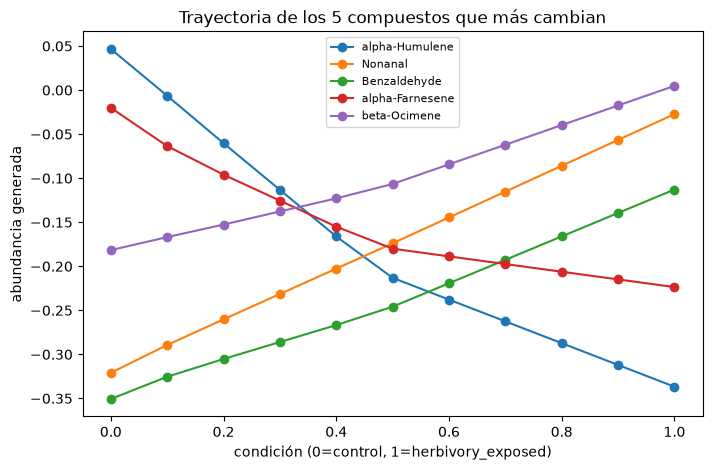

In [20]:
top5 = cambios.head(5)["compuesto_id"].tolist()
idx_top5 = [list(compound_ids).index(cid) for cid in top5]

plt.figure(figsize=(8, 5))
for i, cid in zip(idx_top5, top5):
    nombre = compuestos.loc[compuestos["compuesto_id"] == cid, "name_original"].values
    etiqueta = nombre[0] if len(nombre) else cid
    plt.plot(c_steps.flatten(), perfiles_generados[:, i], marker="o", label=etiqueta)

plt.xlabel("condición (0=control, 1=herbivory_exposed)")
plt.ylabel("abundancia generada")
plt.legend(fontsize=8)
plt.title("Trayectoria de los 5 compuestos que más cambian")
plt.show()

# Etapa 4

In [21]:
# Isolation forest
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import LeaveOneOut

X_real_ayelo = np.vstack([X_train_s, X_val_s])
n_real_ayelo = X_real_ayelo.shape[0]
print(f"Muestras reales (algodón): {n_real_ayelo}")

iso_final_ayelo = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
iso_final_ayelo.fit(X_real_ayelo)

loo = LeaveOneOut()
scores_loo_ayelo = np.zeros(n_real_ayelo)
for train_idx, test_idx in loo.split(X_real_ayelo):
    iso_fold = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
    iso_fold.fit(X_real_ayelo[train_idx])
    scores_loo_ayelo[test_idx[0]] = -iso_fold.score_samples(X_real_ayelo[test_idx])[0]

print("Distribución LOO IF:")
print(pd.Series(scores_loo_ayelo).describe())

Muestras reales (algodón): 60
Distribución LOO IF:
count    60.000000
mean      0.495266
std       0.053507
min       0.401910
25%       0.451004
50%       0.497564
75%       0.518800
max       0.625228
dtype: float64


In [22]:
# # % de la distrib de referncia queda debajo de score 
def percentil_vs_referencia(score, referencia):
    return (referencia < score).mean() * 100

score_generados_ayelo = -iso_final_ayelo.score_samples(perfiles_generados)
percentiles_ayelo = np.array([percentil_vs_referencia(s, scores_loo_ayelo) for s in score_generados_ayelo])

resultado_ayelo = pd.DataFrame({
    "paso_condicion": c_steps.flatten(),
    "score_isolation_forest": score_generados_ayelo,
    "percentil_if_vs_reales": percentiles_ayelo,
})
resultado_ayelo

,paso_condicion,score_isolation_forest,percentil_if_vs_reales
0,0.0,0.480240,40.000000
1,0.1,0.479884,38.333333
2,0.2,0.473521,38.333333
3,0.3,0.472706,36.666667
4,0.4,0.469280,36.666667
5,0.5,0.466629,35.000000
6,0.6,0.466221,35.000000
7,0.7,0.466173,35.000000
8,0.8,0.465603,35.000000
9,0.9,0.464977,35.000000


In [23]:
# Extrapolación para ver mas allá en una condición mayor a infected.
n_steps_extra = 11
c_steps_extra = np.linspace(1.0, 2.0, n_steps_extra).reshape(-1, 1)
z_repeated_extra = np.repeat(z_fixed, n_steps_extra, axis=0)

perfiles_extrapolados_ayelo = decoder.predict([z_repeated_extra, c_steps_extra])
score_extrapolados_ayelo = -iso_final_ayelo.score_samples(perfiles_extrapolados_ayelo)
percentiles_extrapolados_ayelo = np.array(
    [percentil_vs_referencia(s, scores_loo_ayelo) for s in score_extrapolados_ayelo]
)

resultado_extrapolado_ayelo = pd.DataFrame({
    "paso_condicion": c_steps_extra.flatten(),
    "score_isolation_forest": score_extrapolados_ayelo,
    "percentil_if_vs_reales": percentiles_extrapolados_ayelo,
})
resultado_extrapolado_ayelo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


,paso_condicion,score_isolation_forest,percentil_if_vs_reales
0,1.0,0.463442,35.000000
1,1.1,0.463761,35.000000
2,1.2,0.464051,35.000000
3,1.3,0.461532,33.333333
4,1.4,0.462373,35.000000
5,1.5,0.462408,35.000000
6,1.6,0.460837,33.333333
7,1.7,0.461262,33.333333
8,1.8,0.461046,33.333333
9,1.9,0.460775,31.666667


In [24]:
# Detector no condicional, independiente del CVAE
def build_autoencoder(input_dim, bottleneck=4):
    inputs = tf.keras.Input(shape=(input_dim,))
    encoded = layers.Dense(16, activation="relu")(inputs)
    encoded = layers.Dense(8, activation="relu")(encoded)
    encoded = layers.Dense(bottleneck, activation="relu")(encoded)
    decoded = layers.Dense(8, activation="relu")(encoded)
    decoded = layers.Dense(16, activation="relu")(decoded)
    decoded = layers.Dense(input_dim, activation="linear")(decoded)
    ae = tf.keras.Model(inputs, decoded)
    ae.compile(optimizer="adam", loss="mse")
    return ae

def recon_error(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean((X - X_hat) ** 2, axis=1)

AE_EPOCHS = 150
AE_BATCH = 8

ae_final_ayelo = build_autoencoder(X_real_ayelo.shape[1])
ae_final_ayelo.fit(X_real_ayelo, X_real_ayelo, epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)

loo = LeaveOneOut()
errores_loo_ae_ayelo = np.zeros(n_real_ayelo)
for train_idx, test_idx in loo.split(X_real_ayelo):
    ae_fold = build_autoencoder(X_real_ayelo.shape[1])
    ae_fold.fit(X_real_ayelo[train_idx], X_real_ayelo[train_idx], epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)
    errores_loo_ae_ayelo[test_idx[0]] = recon_error(ae_fold, X_real_ayelo[test_idx])[0]

print("Distribución LOO autoencoder:")
print(pd.Series(errores_loo_ae_ayelo).describe())

Distribución LOO autoencoder:
count    60.000000
mean      0.216345
std       0.207130
min       0.011318
25%       0.097893
50%       0.170181
75%       0.247942
max       1.093794
dtype: float64


In [25]:
# Control + para validar 
z_extremo_ayelo = np.full((1, latent_dim), 5.0)
c_extremo_ayelo = np.array([[1.0]])
perfil_control_positivo_ayelo = decoder.predict([z_extremo_ayelo, c_extremo_ayelo])

score_if_control_ayelo = -iso_final_ayelo.score_samples(perfil_control_positivo_ayelo)[0]
error_ae_control_ayelo = recon_error(ae_final_ayelo, perfil_control_positivo_ayelo)[0]

print(f"  Score Isolation Forest: {score_if_control_ayelo:.4f}  (percentil {percentil_vs_referencia(score_if_control_ayelo, scores_loo_ayelo):.1f}%)")
print(f"  Error autoencoder:      {error_ae_control_ayelo:.4f}  (percentil {percentil_vs_referencia(error_ae_control_ayelo, errores_loo_ae_ayelo):.1f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
  Score Isolation Forest: 0.6167  (percentil 95.0%)
  Error autoencoder:      1.6451  (percentil 100.0%)


In [26]:
# Ver si el decoder se satura con z más extremo
for mag in [5, 10, 20, 50]:
    z_test = np.full((1, latent_dim), float(mag))
    perfil_test = decoder.predict([z_test, c_extremo_ayelo], verbose=0)
    s_if = -iso_final_ayelo.score_samples(perfil_test)[0]
    e_ae = recon_error(ae_final_ayelo, perfil_test)[0]
    print(f"z={mag}: IF percentil {percentil_vs_referencia(s_if, scores_loo_ayelo):.1f}%  "
          f"AE percentil {percentil_vs_referencia(e_ae, errores_loo_ae_ayelo):.1f}%")

z=5: IF percentil 95.0%  AE percentil 100.0%
z=10: IF percentil 100.0%  AE percentil 100.0%
z=20: IF percentil 100.0%  AE percentil 100.0%
z=50: IF percentil 100.0%  AE percentil 100.0%


In [27]:
# Clasificación final
error_generados_ayelo = recon_error(ae_final_ayelo, perfiles_generados)
error_extrapolados_ayelo = recon_error(ae_final_ayelo, perfiles_extrapolados_ayelo)

resultado_ayelo["percentil_ae_vs_reales"] = [
    percentil_vs_referencia(e, errores_loo_ae_ayelo) for e in error_generados_ayelo
]
resultado_extrapolado_ayelo["percentil_ae_vs_reales"] = [
    percentil_vs_referencia(e, errores_loo_ae_ayelo) for e in error_extrapolados_ayelo
]

def clasificar(perc_if, perc_ae=None):
    percentiles = [p for p in [perc_if, perc_ae] if p is not None]
    if all(p > 97.5 for p in percentiles):
        return "novedoso"
    elif all(p < 90 for p in percentiles):
        return "plausible"
    else:
        return "frontera"

resultado_ayelo["clasificacion"] = [
    clasificar(row.percentil_if_vs_reales, row.percentil_ae_vs_reales)
    for row in resultado_ayelo.itertuples()
]
resultado_extrapolado_ayelo["clasificacion"] = [
    clasificar(row.percentil_if_vs_reales, row.percentil_ae_vs_reales)
    for row in resultado_extrapolado_ayelo.itertuples()
]

print("Gradiente observado (control a herbivory_exposed):")
print(resultado_ayelo[["paso_condicion", "clasificacion"]])
print("\nExtrapolación:")
print(resultado_extrapolado_ayelo[["paso_condicion", "clasificacion"]])

Gradiente observado (control a herbivory_exposed):
    paso_condicion clasificacion
0              0.0     plausible
1              0.1     plausible
2              0.2     plausible
3              0.3     plausible
4              0.4     plausible
5              0.5     plausible
6              0.6     plausible
7              0.7     plausible
8              0.8     plausible
9              0.9     plausible
10             1.0     plausible

Extrapolación:
    paso_condicion clasificacion
0              1.0     plausible
1              1.1     plausible
2              1.2     plausible
3              1.3     plausible
4              1.4     plausible
5              1.5     plausible
6              1.6     plausible
7              1.7     plausible
8              1.8     plausible
9              1.9     plausible
10             2.0     plausible


In [28]:
# Revisar frontera
resultado_extrapolado_ayelo[["paso_condicion", "percentil_if_vs_reales", "percentil_ae_vs_reales", "clasificacion"]]

,paso_condicion,percentil_if_vs_reales,percentil_ae_vs_reales,clasificacion
0,1.0,35.000000,13.333333,plausible
1,1.1,35.000000,13.333333,plausible
2,1.2,35.000000,13.333333,plausible
3,1.3,33.333333,13.333333,plausible
4,1.4,35.000000,11.666667,plausible
5,1.5,35.000000,11.666667,plausible
6,1.6,33.333333,11.666667,plausible
7,1.7,33.333333,11.666667,plausible
8,1.8,33.333333,11.666667,plausible
9,1.9,31.666667,11.666667,plausible


In [29]:
#Resúmen
def resumen_especie(nombre_especie, detectores_usados, *tablas_clasificadas):
    todas = pd.concat(tablas_clasificadas, ignore_index=True)
    n = len(todas)
    conteo = todas["clasificacion"].value_counts(normalize=True).mul(100).round(1)
    return {
        "especie": nombre_especie,
        "detectores": detectores_usados,
        "n_perfiles_evaluados": n,
        "% plausible": conteo.get("plausible", 0.0),
        "% frontera": conteo.get("frontera", 0.0),
        "% novedoso": conteo.get("novedoso", 0.0),
    }

fila_ayelo = resumen_especie("Ayelo 2026", "IF + AE", resultado_ayelo, resultado_extrapolado_ayelo)
pd.DataFrame([fila_ayelo])

,especie,detectores,n_perfiles_evaluados,% plausible,% frontera,% novedoso
0,Ayelo 2026,IF + AE,22,100.0,0.0,0.0


In [30]:
export_cvae(
    "ayelo2026",
    encoder=encoder, decoder=decoder, iso_forest=iso_final_ayelo, autoencoder=ae_final_ayelo,
    scores_loo=scores_loo_ayelo, errores_loo_ae=errores_loo_ae_ayelo, scaler=scaler, compound_ids=compound_ids,
    meta={"especie": "Gossypium hirsutum (Ayelo 2026)"}
)

Exportado CVAE+detectores: ayelo2026 -> ..\models\ayelo2026
